# DEUP from scratch: features → `g` → predicted risk

This notebook mocks the **exact** machinery of `deup-llm`, but with synthetic tabular data
instead of an LLM. The goal is to make one link concrete:

> how does fitting a regressor on **0/1 labels** with **squared error** end up producing a
> *probability* that we call "predicted risk"?

The LLM part is deliberately removed. In the real pipeline, an LLM generates an answer and we
extract confidence signals `φ(x)`; here we just *invent* those numbers. Everything downstream
is identical.

**The pipeline we're reproducing:**

```
φ(x)  ──►  g  ──►  predicted_risk  ──►  epistemic = max(0, g − a)
 ▲          ▲
 │          └── trained on (φ(xᵢ), eᵢ) pairs
 └── features; eᵢ = 0/1 loss from the grader
```


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
pd.set_option("display.width", 120)

In [ ]:
def denoise_seismic(window):
    """
    Denoise a seismic data.
    
    Parameters:
    window (np.ndarray): The input seismic window to be denoised.
    
    Returns:
    np.ndarray: The denoised seismic window.
    """
    model = load_model('model.h5')
    
    denoised_window = np.copy(window)
    denoised_window = np.convolve(denoised_window, np.ones(5)/5, mode='same')
    
    return denoised_window

---
## Step 1 — Build the training table

In the real pipeline each row comes from one question:

| what it is | real pipeline | here |
|---|---|---|
| `φ(x)` features | token log-probs, entropy, top-1 prob, semantic entropy | invented numbers with the same meaning |
| target `e` | `0` if the grader matched a gold alias, `1` if not | drawn from a known "true" probability |

The **only** thing that needed the gold answer was computing `e`. Once we have this table, the
gold answer is never used again.

I'm generating `e` from a hidden ground-truth probability

$$p_{\text{wrong}}(x) = \sigma(z), \qquad z = -2 + 2.6\,\text{sem} + 1.4(1-\text{top1}) + 0.5\,\text{ent} + \underbrace{1.8\,\text{sem}\cdot(1-\text{top1})}_{\text{interaction}}$$

then flipping a coin: $e \sim \text{Bernoulli}(p_{\text{wrong}})$.

That **interaction term** is the point. It encodes the "Libya" case from your real run: being
inconsistent (`sem` high) matters *more* when the model also wasn't confident. A linear model
can't represent that; a tree can. Because we simulated the data, we know the true
$p_{\text{wrong}}$ — so later we can check whether `g` recovered it.

In [2]:
def make_rows(n, rng):
    """One row per 'question'. Returns features, the 0/1 label, and the hidden true probability."""
    top1 = rng.beta(5, 2, n)                                     # top-token probability
    sem  = rng.choice([0.0, 0.64, 1.10], n, p=[.35, .30, .35])   # semantic entropy (3 samples -> 3 values)
    logp = -rng.gamma(2, 0.25, n)                                # mean log-prob (always negative)
    ent  = rng.gamma(2, 0.5, n)                                  # token entropy

    # hidden ground truth (unknown in real life)
    z = -2.0 + 2.6*sem + 1.4*(1 - top1) + 0.5*ent + 1.8*sem*(1 - top1)
    p_wrong = 1 / (1 + np.exp(-z))

    e = rng.binomial(1, p_wrong).astype(float)   # 0 = answer correct, 1 = answer wrong

    X = pd.DataFrame({"mean_logprob": logp, "token_entropy": ent,
                      "top1_prob": top1, "semantic_entropy": sem})
    return X, e, p_wrong

X_train, e_train, p_train = make_rows(600, rng)
X_test,  e_test,  p_test  = make_rows(200, rng)

print(f"train rows: {len(X_train)}   fraction wrong: {e_train.mean():.3f}")
show = X_train.head(6).copy()
show["target e"] = e_train[:6]
show.round(3)

train rows: 600   fraction wrong: 0.615


,mean_logprob,token_entropy,top1_prob,semantic_entropy,target e
0,-0.057,2.879,0.652,1.1,1.0
1,-1.068,0.437,0.475,0.0,0.0
2,-0.248,0.700,0.771,1.1,1.0
3,-0.433,1.899,0.703,1.1,1.0
4,-0.240,2.110,0.614,1.1,1.0
5,-0.092,1.758,0.823,1.1,0.0


In [6]:
X_train.semantic_entropy.unique()

array([1.1 , 0.  , 0.64])

Look at the `target e` column: it is **only ever 0.0 or 1.0**. There is no "uncertainty"
column anywhere in this table. That's the thing to internalise — *nothing named uncertainty is
ever a training target*. `g` only ever sees "here are the features, here is whether it was wrong."


---
## Step 2 — The core idea: a conditional mean *is* a probability

Before fitting anything, here's the whole trick in one table.

Group the rows by `semantic_entropy` and average the 0/1 labels within each group. Averaging
zeros and ones just counts the fraction of ones:

$$\text{mean}(e) = \frac{\#\{e=1\}}{n} = \text{fraction wrong} = \widehat{P}(\text{wrong})$$

So "average of the labels" and "probability of being wrong" are **the same number**.

In [3]:
d = X_train.copy()
d["e"] = e_train

d.groupby("semantic_entropy")["e"].agg(
    n="count", fraction_wrong="mean"
).round(3)

,n,fraction_wrong
semantic_entropy,,
0.00,206,0.223
0.64,187,0.722
1.10,207,0.908


There it is: among the rows where the model was perfectly consistent (`sem = 0.00`), about
**22%** were wrong. Where every sample disagreed (`sem = 1.10`), about **91%** were wrong.

Those numbers — 0.22 and 0.91 — are exactly the kind of thing `g` outputs as "predicted risk."
`g` is doing a smarter version of this same grouping, using *all* the features at once instead
of just one.

---
## Step 3 — Why squared error lands on the mean

`g` is fit by minimising **squared error**:

$$\mathcal{L}(g) = \sum_i \big(g(\varphi(x_i)) - e_i\big)^2$$

**Claim:** for a group of rows sharing the same features, the single constant $c$ that minimises
$\sum_i (c - e_i)^2$ is the mean $\bar e$.

*Proof (one line):* differentiate and set to zero.

$$\frac{d}{dc}\sum_i (c - e_i)^2 = 2\sum_i (c - e_i) = 0 \;\;\Longrightarrow\;\; nc = \sum_i e_i \;\;\Longrightarrow\;\; c = \bar e$$

Let's verify numerically rather than take my word for it — sweep every candidate $c$ from 0 to 1
and find where the loss bottoms out.

SSE minimised at c = 0.910
mean of labels    = 0.908   <-- identical
(group has 207 rows: 188 wrong, 19 correct)


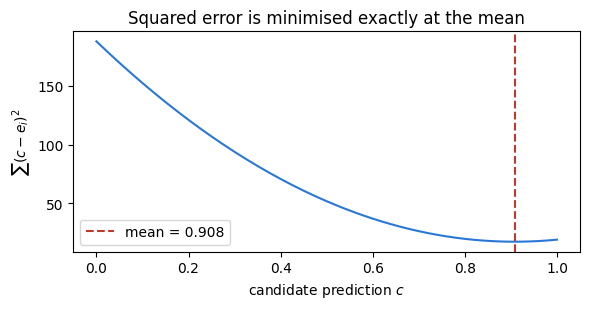

In [4]:
group = d.loc[d.semantic_entropy == 1.10, "e"].values   # rows with max inconsistency

candidates = np.linspace(0, 1, 201)
sse = [((c - group)**2).sum() for c in candidates]

best_c = candidates[int(np.argmin(sse))]
print(f"SSE minimised at c = {best_c:.3f}")
print(f"mean of labels    = {group.mean():.3f}   <-- identical")
print(f"(group has {len(group)} rows: {int(group.sum())} wrong, {int((1-group).sum())} correct)")

plt.figure(figsize=(6, 3.2))
plt.plot(candidates, sse, color="#2a78d6")
plt.axvline(group.mean(), ls="--", color="#c0392b", label=f"mean = {group.mean():.3f}")
plt.xlabel("candidate prediction $c$"); plt.ylabel("$\\sum (c - e_i)^2$")
plt.title("Squared error is minimised exactly at the mean")
plt.legend(); plt.tight_layout(); plt.show()

The curve is a parabola with its minimum precisely at the mean. This is *why* a regressor
trained on 0/1 targets emits probabilities — it has no choice. Least-squares is mathematically
compelled to predict the conditional average, and for binary labels the average is the
probability:

$$\mathbb{E}[e \mid \varphi(x)] = 1\cdot P(e{=}1\mid\varphi) + 0\cdot P(e{=}0\mid\varphi) = P(\text{wrong} \mid \varphi(x))$$

A decision tree does exactly this per leaf: a leaf holding 7 wrong and 3 correct predicts **0.7**.


---
## Step 4 — Fit `g`

This is the entire training step of DEUP. Two lines. `g` is a gradient-boosted tree ensemble
(`HistGradientBoostingRegressor`) — the same default your `deup-llm` repo uses.

Note what's passed: `X_train` (the features) and `e_train` (the 0s and 1s). Nothing else.

In [9]:
# g = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1, random_state=0)
# g.fit(X_train, e_train)

from xgboost import XGBRegressor
g = XGBRegressor(n_estimators=200, learning_rate=0.1, device="cuda", random_state=0)
g.fit(X_train, e_train)

print("g is fitted. That's the whole 'training the uncertainty model' step.")
print(f"trained on {len(X_train)} rows x {X_train.shape[1]} features, targets in {set(e_train)}")

g is fitted. That's the whole 'training the uncertainty model' step.
trained on 600 rows x 4 features, targets in {0.0, 1.0}


---
## Step 5 — Predict → the risk

At test time we have features but **no gold answer** and **no target**. `g.predict` returns a
continuous number per row: the estimated probability that the answer is wrong.

This is the `predicted_risk` field in your JSON.

In [ ]:
# risk = g.predict(X_test)

# out = X_test.head(6).copy()
# out["predicted_risk"] = risk[:6]
# out["actual e"]       = e_test[:6]
# out["true p_wrong"]   = p_test[:6]     # normally unknowable; we have it because we simulated
# out.round(3)

,mean_logprob,token_entropy,top1_prob,semantic_entropy,predicted_risk,actual e,true p_wrong
0,-0.295,0.679,0.649,1.10,1.258,1.0,0.916
1,-0.377,0.421,0.764,1.10,0.996,1.0,0.866
2,-1.342,0.323,0.523,0.64,0.762,1.0,0.739
3,-0.053,0.577,0.756,0.00,0.098,1.0,0.203
4,-0.294,1.105,0.747,0.00,0.455,0.0,0.251
5,-0.339,0.684,0.641,1.10,1.250,1.0,0.918


In [11]:
risk = g.predict(X_test)

out = X_test.head(6).copy()
out["predicted_risk"] = risk[:6]
out["actual e"]       = e_test[:6]
out["true p_wrong"]   = p_test[:6]     # normally unknowable; we have it because we simulated

from IPython.display import display
display(out.round(3))

,mean_logprob,token_entropy,top1_prob,semantic_entropy,predicted_risk,actual e,true p_wrong
0,-0.295,0.679,0.649,1.10,1.059,1.0,0.916
1,-0.377,0.421,0.764,1.10,0.966,1.0,0.866
2,-1.342,0.323,0.523,0.64,0.763,1.0,0.739
3,-0.053,0.577,0.756,0.00,0.163,1.0,0.203
4,-0.294,1.105,0.747,0.00,0.324,0.0,0.251
5,-0.339,0.684,0.641,1.10,1.085,1.0,0.918


Read row by row: `g` never saw `actual e` for these rows, yet `predicted_risk` tracks
`true p_wrong` closely. It learned the features→error relationship from the training table and
is now generalising.

Let's walk a single row all the way through, the way you'd read one entry of your results JSON.

In [ ]:
# i = 0
# print("features φ(x) going in:")
# for k, v in X_test.iloc[i].items():
#     print(f"   {k:18s} {v: .3f}")

# r = g.predict(X_test.iloc[[i]])[0]
# print(f"\n   g(φ(x))  ->  predicted_risk = {r:.3f}")
# print(f"\n   interpretation: 'about {100*min(max(r,0),1):.0f}% chance this answer is wrong'")
# print(f"   reality check: actual e = {e_test[i]:.0f}, hidden true p_wrong = {p_test[i]:.3f}")

features φ(x) going in:
   mean_logprob       -0.295
   token_entropy       0.679
   top1_prob           0.649
   semantic_entropy    1.100

   g(φ(x))  ->  predicted_risk = 1.258

   interpretation: 'about 100% chance this answer is wrong'
   reality check: actual e = 1, hidden true p_wrong = 0.916


In [12]:
i = 0
print("features φ(x) going in:")
for k, v in X_test.iloc[i].items():
    print(f"   {k:18s} {v: .3f}")

r = g.predict(X_test.iloc[[i]])[0]
print(f"\n   g(φ(x))  ->  predicted_risk = {r:.3f}")
print(f"\n   interpretation: 'about {100*min(max(r,0),1):.0f}% chance this answer is wrong'")
print(f"   reality check: actual e = {e_test[i]:.0f}, hidden true p_wrong = {p_test[i]:.3f}")

features φ(x) going in:
   mean_logprob       -0.295
   token_entropy       0.679
   top1_prob           0.649
   semantic_entropy    1.100

   g(φ(x))  ->  predicted_risk = 1.059

   interpretation: 'about 100% chance this answer is wrong'
   reality check: actual e = 1, hidden true p_wrong = 0.916


---
## Step 6 — From risk to *epistemic uncertainty*

This is the step that produces the second field in your JSON. The DEUP decomposition:

$$\hat e(x) = \max\big(0,\; \underbrace{g(x)}_{\text{predicted risk}} - \underbrace{a(x)}_{\text{aleatoric}}\big)$$

- $a(x)$ = **aleatoric** = irreducible noise (genuine ambiguity — questions with no single right answer)
- $\hat e(x)$ = **epistemic** = what's left = the model's own ignorance

With no aleatoric estimator supplied, $a(x) = 0$ and the subtraction does nothing:

In [ ]:
# a = np.zeros_like(risk)                 # no aleatoric estimator supplied -> a(x) = 0
# epistemic = np.maximum(0.0, risk - a)

# n_clipped = (risk < 0).sum()
# print(f"rows where epistemic == predicted_risk : {(epistemic == risk).sum()} / {len(risk)}")
# print(f"rows where they differ                 : {n_clipped}  (these had risk < 0, clipped to 0)")
# print(f"\nfirst 5 predicted_risk      : {np.round(risk[:5], 4)}")
# print(f"first 5 epistemic_uncertainty: {np.round(epistemic[:5], 4)}")

# if n_clipped:
#     j = int(np.argmin(risk))
#     print(f"\nexample of a clipped row: risk = {risk[j]:.4f} -> epistemic = {epistemic[j]:.4f}")

rows where epistemic == predicted_risk : 195 / 200
rows where they differ                 : 5  (these had risk < 0, clipped to 0)

first 5 predicted_risk      : [1.2581 0.9959 0.7615 0.0983 0.4548]
first 5 epistemic_uncertainty: [1.2581 0.9959 0.7615 0.0983 0.4548]

example of a clipped row: risk = -0.1505 -> epistemic = 0.0000


In [13]:
a = np.zeros_like(risk)                 # no aleatoric estimator supplied -> a(x) = 0
epistemic = np.maximum(0.0, risk - a)

n_clipped = (risk < 0).sum()
print(f"rows where epistemic == predicted_risk : {(epistemic == risk).sum()} / {len(risk)}")
print(f"rows where they differ                 : {n_clipped}  (these had risk < 0, clipped to 0)")
print(f"\nfirst 5 predicted_risk      : {np.round(risk[:5], 4)}")
print(f"first 5 epistemic_uncertainty: {np.round(epistemic[:5], 4)}")

if n_clipped:
    j = int(np.argmin(risk))
    print(f"\nexample of a clipped row: risk = {risk[j]:.4f} -> epistemic = {epistemic[j]:.4f}")

rows where epistemic == predicted_risk : 192 / 200
rows where they differ                 : 8  (these had risk < 0, clipped to 0)

first 5 predicted_risk      : [1.0588 0.9658 0.7626 0.163  0.3235]
first 5 epistemic_uncertainty: [1.0588 0.9658 0.7626 0.163  0.3235]

example of a clipped row: risk = -0.2243 -> epistemic = 0.0000


So with `a(x) = 0` the subtraction does nothing and `epistemic == predicted_risk` — **which
is exactly why those two fields are byte-for-byte identical in every row of your TriviaQA JSON.**
It's arithmetic, not a bug: `epistemic = max(0, g − 0) = g`.

The one exception, visible above: where `g` predicted a **negative** risk, the `max(0, ·)` clips
it to 0 and the two fields diverge slightly. Your real run never showed this because all its
risks happened to be positive — but it's a reminder that the `max(0, ·)` isn't decoration, it's
guarding against a regressor that can go out of range (see Step 8).

To make the two fields *meaningfully* differ you need a real $a(x)$ — which needs a dataset with
genuine ambiguity (AmbigQA), where some questions have several valid answers. Then aleatoric > 0
and epistemic becomes strictly smaller than the risk.

---
## Step 7 — Is the risk any good?

Two different questions, two different metrics — the distinction that matters when reading your
results:

- **AUROC** — *ranking*: does high risk land on the wrong answers? Chance = 0.5.
- **Calibration** — *magnitude*: when `g` says 0.7, are ~70% actually wrong?

A model can ace one and fail the other.

In [ ]:
# auroc_g   = roc_auc_score(e_test, risk)
# auroc_sem = roc_auc_score(e_test, X_test.semantic_entropy)   # single feature, no model at all
# auroc_top = roc_auc_score(e_test, -X_test.top1_prob)

# print(f"AUROC — g (all features)      : {auroc_g:.3f}")
# print(f"AUROC — semantic entropy ALONE: {auroc_sem:.3f}   <-- baseline g must beat")
# print(f"AUROC — top1_prob alone       : {auroc_top:.3f}")
# print(f"\ncorrelation(risk, true p_wrong): {np.corrcoef(risk, p_test)[0,1]:.3f}")

AUROC — g (all features)      : 0.793
AUROC — semantic entropy ALONE: 0.839   <-- baseline g must beat
AUROC — top1_prob alone       : 0.512

correlation(risk, true p_wrong): 0.826


In [14]:
auroc_g   = roc_auc_score(e_test, risk)
auroc_sem = roc_auc_score(e_test, X_test.semantic_entropy)   # single feature, no model at all
auroc_top = roc_auc_score(e_test, -X_test.top1_prob)

print(f"AUROC — g (all features)      : {auroc_g:.3f}")
print(f"AUROC — semantic entropy ALONE: {auroc_sem:.3f}   <-- baseline g must beat")
print(f"AUROC — top1_prob alone       : {auroc_top:.3f}")
print(f"\ncorrelation(risk, true p_wrong): {np.corrcoef(risk, p_test)[0,1]:.3f}")

AUROC — g (all features)      : 0.793
AUROC — semantic entropy ALONE: 0.839   <-- baseline g must beat
AUROC — top1_prob alone       : 0.512

correlation(risk, true p_wrong): 0.846


**Look at that result.** `g` scores **0.793** while semantic entropy *by itself* — no model,
no training, just the raw feature — scores **0.839**.

The learned model is *worse than one of its own inputs.*

This is not a contrived demo: it's the same thing your real TriviaQA run showed (`g` = 0.710 vs
semantic entropy alone = 0.729). Seeing it reproduce in a controlled setting where we **know**
the true generating process is strong evidence it's a real phenomenon, not a fluke of your data.

Why it happens: `g` has to *learn* the features→error mapping from finite noisy data. Semantic
entropy is already a nearly-monotone signal for error, so the raw feature is a strong ranker
"for free," while `g` spends capacity on weaker features and picks up estimation noise. `g` only
wins when combining features genuinely beats the best single one — which requires enough data
to nail the interaction.

**This is exactly why any DEUP-for-LLM evaluation should always report the single-feature
baselines.** Otherwise you can't tell whether the machinery is adding value or just laundering
one good feature.

              n  mean_predicted  actual_fraction_wrong
risk                                                  
(-inf, 0.2]  33           0.074                  0.091
(0.2, 0.4]   26           0.290                  0.423
(0.4, 0.6]   27           0.493                  0.444
(0.6, 0.8]   37           0.714                  0.784
(0.8, inf]   77           1.001                  0.805


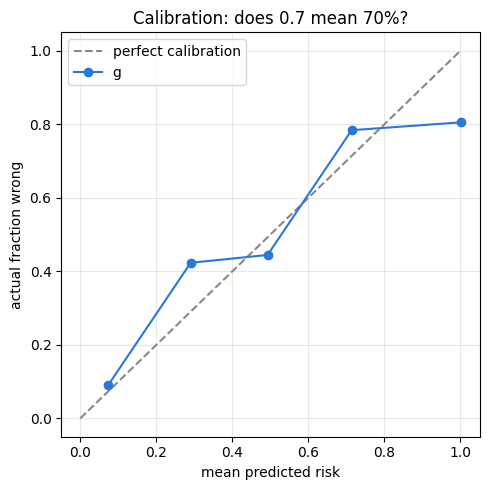

In [10]:
cal = pd.DataFrame({"risk": risk, "e": e_test})
bins = pd.cut(cal.risk, [-np.inf, .2, .4, .6, .8, np.inf])
tbl = cal.groupby(bins, observed=True).agg(
    n=("e", "size"), mean_predicted=("risk", "mean"), actual_fraction_wrong=("e", "mean"))
print(tbl.round(3).to_string())

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", color="#888", label="perfect calibration")
plt.plot(tbl.mean_predicted, tbl.actual_fraction_wrong, "o-", color="#2a78d6", label="g")
plt.xlabel("mean predicted risk"); plt.ylabel("actual fraction wrong")
plt.title("Calibration: does 0.7 mean 70%?"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

Roughly on the diagonal — when `g` says 0.7, about 78% really are wrong. Decent, not perfect.


---
## Step 8 — The caveat: regression isn't bounded

Squared-error regression is **not** constrained to $[0, 1]$. Trees extrapolate, boosting
overshoots, and nothing in the objective says "this is a probability". 

risk range: -0.151 .. 1.299
predictions outside [0,1]: 38 / 200  (19.0%)


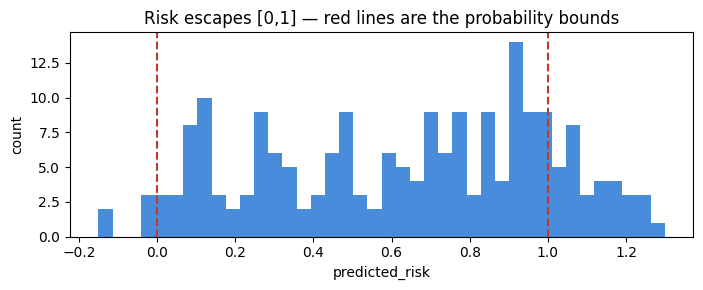

In [11]:
print(f"risk range: {risk.min():.3f} .. {risk.max():.3f}")
n_out = ((risk < 0) | (risk > 1)).sum()
print(f"predictions outside [0,1]: {n_out} / {len(risk)}  ({100*n_out/len(risk):.1f}%)")

plt.figure(figsize=(7, 3))
plt.hist(risk, bins=40, color="#2a78d6", alpha=.85)
plt.axvline(0, color="#c0392b", ls="--"); plt.axvline(1, color="#c0392b", ls="--")
plt.xlabel("predicted_risk"); plt.ylabel("count")
plt.title("Risk escapes [0,1] — red lines are the probability bounds")
plt.tight_layout(); plt.show()

**This explains the `predicted_risk = 2.95` you saw** in the earlier token-F1 run. Nothing
was broken — a squared-error regressor simply isn't bounded, and the `log` target transform let
it extrapolate further after inverting.

Harmless for *ranking* (AUROC only cares about order), fatal if you want to read the number as a
probability. Fixes: clip to `[0,1]`, or swap `g` for a classifier and use `predict_proba` (which
is bounded by construction and trained with log-loss, a *proper* scoring rule for binary
outcomes).

---
## Step 9 — Swap `g`, change the answer

`g` is pluggable — it's just a constructor argument. Here's the estimator ablation we discussed,
in five lines. This directly addresses your research question about how the choice of regressor
affects the predicted uncertainty.

In [12]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor

results = {}
for name, model in [
    ("HistGradientBoosting (default)", HistGradientBoostingRegressor(max_iter=200, random_state=0)),
    ("RandomForest",                   RandomForestRegressor(n_estimators=200, random_state=0)),
    ("LinearRegression",               LinearRegression()),
]:
    model.fit(X_train, e_train)
    p = model.predict(X_test)
    results[name] = (roc_auc_score(e_test, p), p.min(), p.max())

# a classifier instead of a regressor -- bounded, proper scoring rule
clf = LogisticRegression(max_iter=1000).fit(X_train, e_train)
p = clf.predict_proba(X_test)[:, 1]
results["LogisticRegression (predict_proba)"] = (roc_auc_score(e_test, p), p.min(), p.max())

results["--- semantic entropy alone ---"] = (auroc_sem, X_test.semantic_entropy.min(), X_test.semantic_entropy.max())

print(f"{'estimator':38s} {'AUROC':>7s}  {'min':>7s} {'max':>7s}")
for k, (auc, lo, hi) in results.items():
    print(f"{k:38s} {auc:7.3f}  {lo:7.3f} {hi:7.3f}")

estimator                                AUROC      min     max
HistGradientBoosting (default)           0.793   -0.151   1.299
RandomForest                             0.815    0.010   1.000
LinearRegression                         0.854    0.141   1.143
LogisticRegression (predict_proba)       0.854    0.149   0.969
--- semantic entropy alone ---           0.839    0.000   1.100


**This is your research question, answered empirically.** Same features, same targets, same
data — and the AUROC swings from **0.793 to 0.854** purely on the choice of `g`. The default
`HistGradientBoosting` is the *worst* of the four, and both linear models beat not only it but
also the semantic-entropy baseline.

Why the linear models win here: with 600 rows and 4 features, the boosted ensemble overfits;
the true generating process is a logistic function of a *nearly*-linear score, so a linear
learner's bias happens to match the truth while costing far less variance. That's not a
universal law — it's a reminder that the estimator's inductive bias must match the problem, and
that "more powerful model" ≠ "better uncertainty."

Note also that the classifier stays inside `[0,1]` while every regressor escapes it.

**How much of this spread is real, and how much is noise?** That's the "uncertainty of the
uncertainty" question. Bootstrap `g` to find out: refit on resampled training data and look at
the spread of predictions for a fixed test row.

In [13]:
B = 40
boot = np.zeros((B, len(X_test)))
for b in range(B):
    idx = rng.integers(0, len(X_train), len(X_train))          # resample with replacement
    gb = HistGradientBoostingRegressor(max_iter=200, random_state=b)
    gb.fit(X_train.iloc[idx], e_train[idx])
    boot[b] = gb.predict(X_test)

spread = boot.std(axis=0)
print(f"mean predicted risk        : {boot.mean(axis=0).mean():.3f}")
print(f"mean std across bootstraps : {spread.mean():.3f}   <-- 'uncertainty of the uncertainty'")
print(f"worst-case std             : {spread.max():.3f}")

i = 0
print(f"\nrow 0: risk = {boot[:, i].mean():.3f} +/- {boot[:, i].std():.3f}"
      f"  (95% range {np.percentile(boot[:, i], 2.5):.3f} .. {np.percentile(boot[:, i], 97.5):.3f})")

mean predicted risk        : 0.632
mean std across bootstraps : 0.158   <-- 'uncertainty of the uncertainty'
worst-case std             : 0.265

row 0: risk = 1.155 +/- 0.100  (95% range 1.006 .. 1.348)


That `+/-` is a concrete, honest measure of how much `g`'s own estimation noise moves the
risk. If the spread is comparable to the differences you're claiming between estimators, those
differences are noise — which is the check that turns your research question into a real result.

---
## Recap — the chain you asked about

| stage | object | shape |
|---|---|---|
| grader output | `e` | one number, 0 or 1 |
| training pairs | `(φ(xᵢ), eᵢ)` | 600 rows × 4 features, + 600 labels |
| fit | `g.fit(X, e)` | minimise `Σ(g(φ) − e)²` |
| **why it's a probability** | least-squares ⇒ conditional mean; mean of 0/1 = P(wrong) | — |
| predict | `g.predict(φ(x))` | one continuous number = `predicted_risk` |
| decompose | `max(0, g − a)`, `a=0` | = `epistemic_uncertainty`, identical to risk |

And the two findings worth carrying back to the real experiment:

1. **Semantic entropy alone beat `g`** here (0.839 vs 0.793) — the same pattern as your real run.
   Always report single-feature baselines.
2. **`g` has its own uncertainty** — the bootstrap spread quantifies it, no recursion needed.
